#Nonisothermal Semi-batch Reactor with Series Reactions and a Heat Removal Constraint

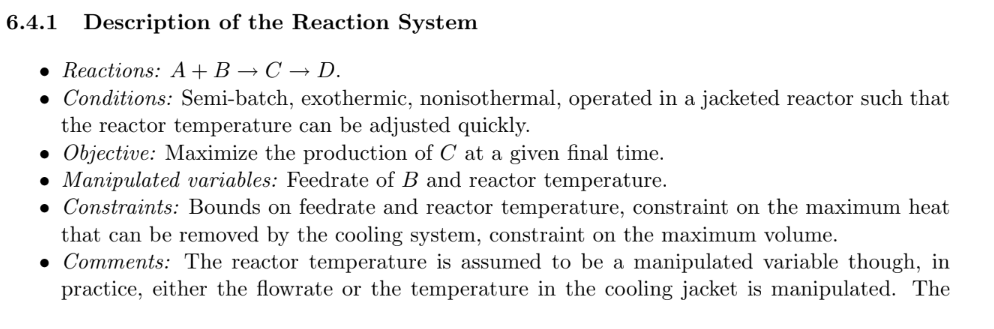

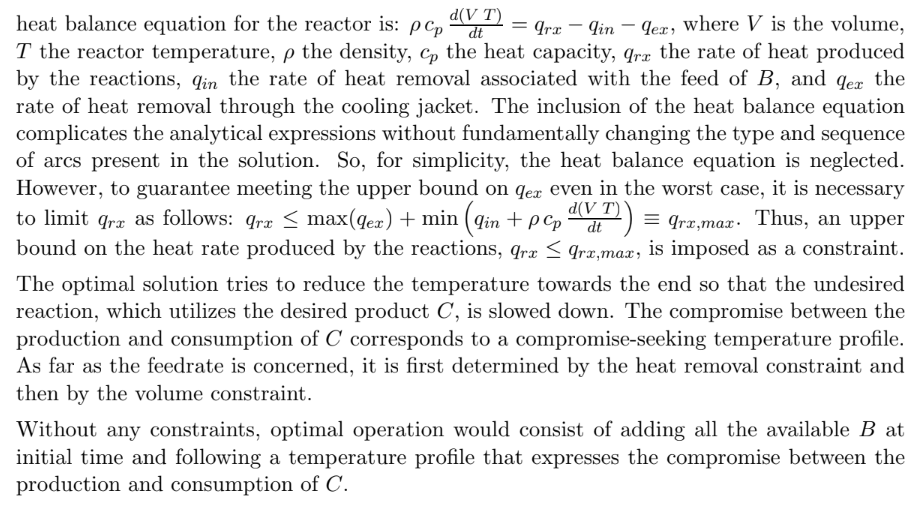

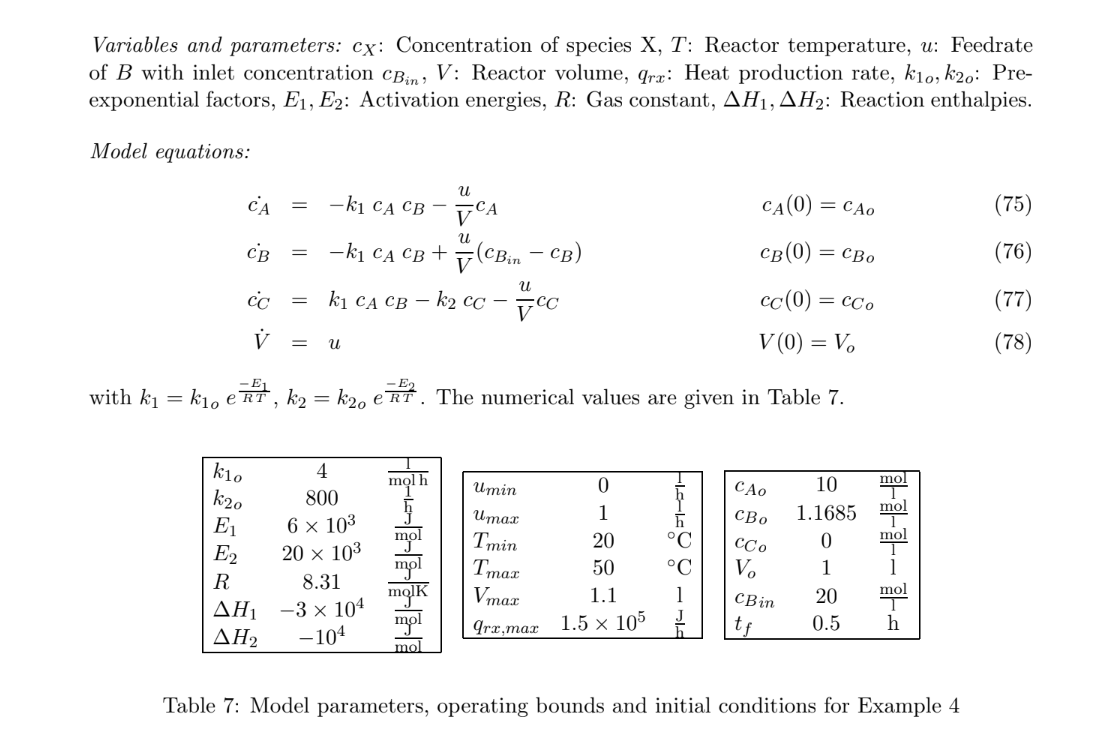

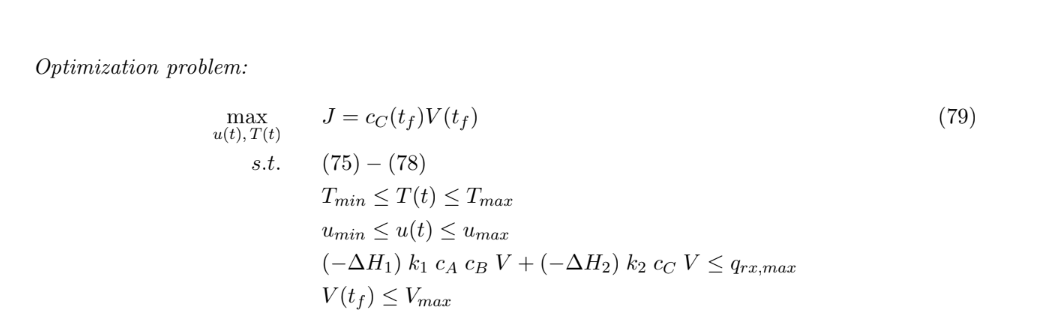

In [ ]:
!pip install casadi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 MB 12.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from casadi import *
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [ ]:
tf = 0.5
N  = 200            # control intervals
dt = tf / N

# initial values
k1_o, k2_o   = 4.0, 800.0
E1, E2       = 6e3, 20e3
R            = 8.314
dH1, dH2     = -3e4, -1e4
cBin         = 20.0

u_min, u_max = 0.0, 1.0
T_min, T_max = 20.0, 50.0
V_max        = 1.1
qrx_max      = 1.5e5

cA_o = 10.0
cB_o = 1.1685
cC_o = 0.0
V_o  = 1.0

6 Inputs: [cA, cB, cC, V, u, T], 4 Outputs: [dcA, dcB, dcC, dV]


In [ ]:
class PINN_Surrogate(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(6, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 4)
        )
    def forward(self, x):
        return self.net(x)


In [ ]:
pytorch_model = PINN_Surrogate()
optimizer = optim.Adam(pytorch_model.parameters(), lr=0.001)
criterion = nn.MSELoss()

approximate values of diffrentials by equating them with the RHS and minimising errors by training

In [ ]:
def true_ode_rhs(state, u_ctrl, T_ctrl):
    cA, cB, cC, V = state
    T_K = T_ctrl + 273.15

    k1 = k1_o * np.exp(-E1 / (R * T_K))
    k2 = k2_o * np.exp(-E2 / (R * T_K))

    dcA = -k1 * cA * cB - (u_ctrl / V) * cA
    dcB = -k1 * cA * cB + (u_ctrl / V) * (cBin - cB)
    dcC =  k1 * cA * cB - k2 * cC - (u_ctrl / V) * cC
    dV  =  u_ctrl

    return np.array([dcA, dcB, dcC, dV])

20000 samples with randomised states. dataloader runs these 20000 models in 1 epoch and then shuffles the array for the next epoch

In [ ]:
num_samples = 20000

# 6 Inputs: [cA, cB, cC, V, u, T], 4 Outputs: [dcA, dcB, dcC, dV]
X_data = np.zeros((num_samples, 6))
Y_data = np.zeros((num_samples, 4))

for i in range(num_samples):
    cA_s = np.random.uniform(0.0, 12.0)
    cB_s = np.random.uniform(0.0, 12.0)
    cC_s = np.random.uniform(0.0, 12.0)
    V_s  = np.random.uniform(1.0, 1.2)
    u_s  = np.random.uniform(u_min, u_max)
    T_s  = np.random.uniform(T_min, T_max)

    X_data[i, :] = [cA_s, cB_s, cC_s, V_s, u_s, T_s]
    Y_data[i, :] = true_ode_rhs([cA_s, cB_s, cC_s, V_s], u_s, T_s)

X_tensor = torch.tensor(X_data, dtype=torch.float32)
Y_tensor = torch.tensor(Y_data, dtype=torch.float32)

dataloader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_tensor, Y_tensor),
    batch_size=512, shuffle=True
)



In [ ]:
epochs = 1000
for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_X, batch_Y in dataloader:
        optimizer.zero_grad()
        loss = criterion(pytorch_model(batch_X), batch_Y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    if (epoch + 1) % 100 == 0:
        print(f"  Epoch [{epoch+1}/{epochs}] - MSE Loss: {epoch_loss/len(dataloader):.6f}")


  Epoch [100/1000] - MSE Loss: 0.336449
  Epoch [200/1000] - MSE Loss: 0.046770
  Epoch [300/1000] - MSE Loss: 0.031926
  Epoch [400/1000] - MSE Loss: 0.011014
  Epoch [500/1000] - MSE Loss: 0.022658
  Epoch [600/1000] - MSE Loss: 0.031854
  Epoch [700/1000] - MSE Loss: 0.005780
  Epoch [800/1000] - MSE Loss: 0.007402
  Epoch [900/1000] - MSE Loss: 0.005882
  Epoch [1000/1000] - MSE Loss: 0.014374



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Total number of variables............................:     1204
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:      804
Total number of inequality constraints...............:     2003
        inequality constraints with only lower bounds:      804
   inequality constraints with lower and upper bounds:      798
        inequality constraints with only upper bounds:      401


Number of Iterations....: 27

     

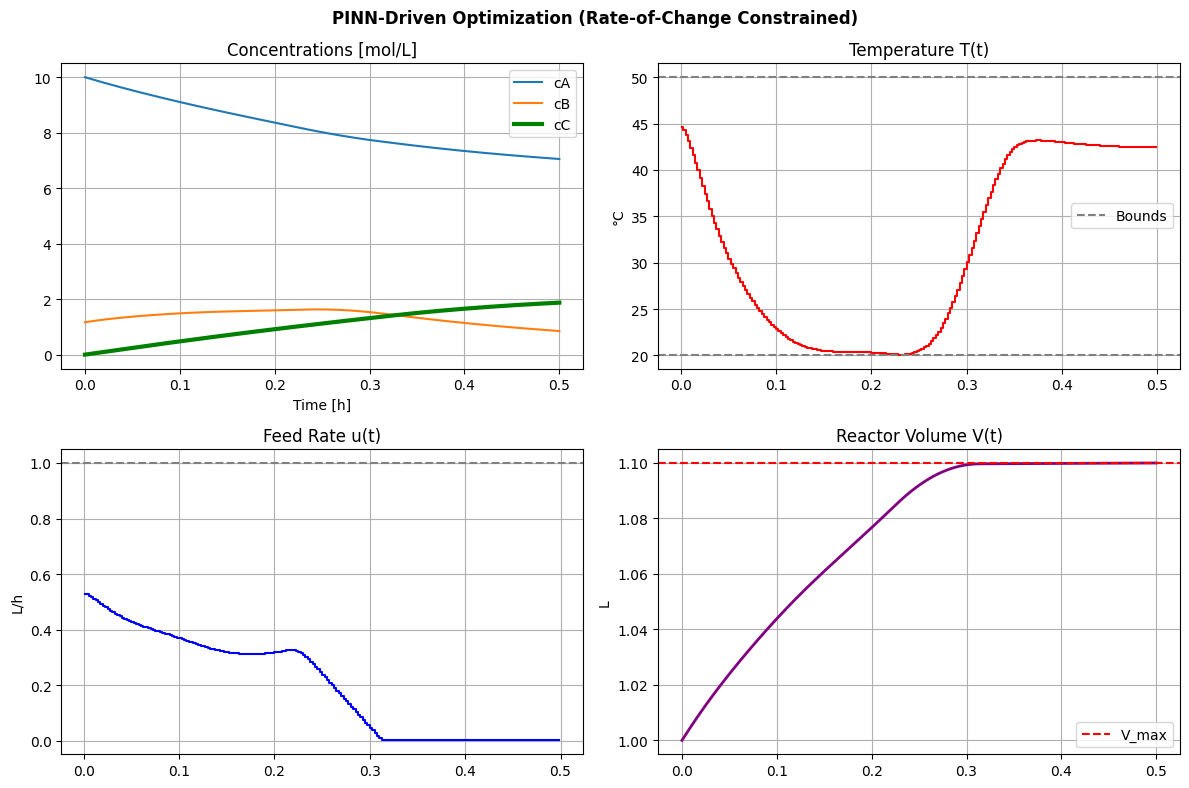

In [ ]:
N=200
def build_casadi_nn(model, input_size=6):
    x_sym = MX.sym('x_nn', input_size)
    out = x_sym

    for layer in model.net:
        if isinstance(layer, nn.Linear):
            W = layer.weight.detach().numpy()
            b = layer.bias.detach().numpy().reshape(-1, 1)
            out = mtimes(W, out) + b
        elif isinstance(layer, nn.Tanh):
            out = tanh(out)

    return Function('pinn_rhs_func', [x_sym], [out])

casadi_pinn_func = build_casadi_nn(pytorch_model)

def pinn_rhs(state, u_ctrl, T_ctrl):
  dx= casadi_pinn_func(vertcat(state, u_ctrl, T_ctrl))
  dx[3] = u_ctrl
  return dx


#optimization step for u and t

opti = Opti()

T_ctrl = opti.variable(N)
u_ctrl = opti.variable(N)
X = opti.variable(4, N + 1) # States: cA, cB, cC, V

# Initial condition
opti.subject_to(X[:, 0] == vertcat(cA_o, cB_o, cC_o, V_o))

def rk4_step_pinn(state, u, T, h):
    k1 = pinn_rhs(state,           u, T)
    k2 = pinn_rhs(state + h/2*k1,  u, T)
    k3 = pinn_rhs(state + h/2*k2,  u, T)
    k4 = pinn_rhs(state + h*k3,    u, T)
    return state + h/6 * (k1 + 2*k2 + 2*k3 + k4)
#numercal integrator function-

for k in range(N):
    x_next = rk4_step_pinn(X[:, k], u_ctrl[k], T_ctrl[k], dt)
    opti.subject_to(X[:, k + 1] == x_next)

    # Heat Constraint
    T_K = T_ctrl[k] + 273.15
    cA_k, cB_k, cC_k, V_k = X[0,k], X[1,k], X[2,k], X[3,k]

    k1_k = k1_o * exp(-E1 / (R * T_K))
    k2_k = k2_o * exp(-E2 / (R * T_K))

    # (-dH1) * k1 * cA * cB * V + (-dH2) * k2 * cC * V <= qrx_max
    q_gen = (-dH1) * k1_k * cA_k * cB_k * V_k + (-dH2) * k2_k * cC_k * V_k
    opti.subject_to(q_gen <= qrx_max)

#T between 20 and 50, u between 0 and 1
opti.subject_to(opti.bounded(T_min, T_ctrl, T_max))
opti.subject_to(opti.bounded(u_min, u_ctrl, u_max))

delta_T_max = 1.0  # max dT
delta_u_max = 0.01  # max du

for k in range(N - 1):
    opti.subject_to(opti.bounded(-delta_T_max, T_ctrl[k+1] - T_ctrl[k], delta_T_max))
    opti.subject_to(opti.bounded(-delta_u_max, u_ctrl[k+1] - u_ctrl[k], delta_u_max))



for k in range(N + 1):
    opti.subject_to(X[3, k] <= V_max)
    opti.subject_to(X[3, k] >= 1.0)
    for i in range(3):
        opti.subject_to(X[i, k] >= 0)

# maximize mC= cC(tf) * V(tf)
opti.minimize( - (X[2, N] * X[3, N]) )

#  guesses for T,u
opti.set_initial(T_ctrl, 30.0 * np.ones(N))
opti.set_initial(u_ctrl, 0.5 * np.ones(N))

# guesses for dcA/dt,dcB/dt,dcC/dt,dV/dt
x_guess = np.array([cA_o, cB_o, cC_o, V_o])
X_guess = [x_guess.copy()]
for k in range(N):
    dx = np.array([-2, 2, 2, 0.2])
    x_guess = np.clip(x_guess + dt * dx, 0, None)
    X_guess.append(x_guess.copy())
opti.set_initial(X, np.array(X_guess).T)


opti.solver("ipopt", {"ipopt.print_level": 3, "ipopt.tol": 1e-4})

try:
    sol = opti.solve()
    obj_val = sol.value(X[2, N] * X[3, N])
    print(f"\n Optimal J = cC(tf)V(tf) = {obj_val:.4f} mol")

    t_grid = np.linspace(0, tf, N + 1)
    t_ctrl = np.linspace(dt/2, tf - dt/2, N)

    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle("PINN-Driven Optimization (Rate-of-Change Constrained)", fontweight="bold")

    axs[0,0].plot(t_grid, sol.value(X[0,:]), label="cA")
    axs[0,0].plot(t_grid, sol.value(X[1,:]), label="cB")
    axs[0,0].plot(t_grid, sol.value(X[2,:]), label="cC", lw=3, color='green')
    axs[0,0].set_title("Concentrations [mol/L]")
    axs[0,0].set_xlabel("Time [h]")
    axs[0,0].legend()
    axs[0,0].grid(True)

    axs[0,1].step(t_ctrl, sol.value(T_ctrl), where="mid", color="r")
    axs[0,1].axhline(T_max, ls="--", color="gray", label="Bounds")
    axs[0,1].axhline(T_min, ls="--", color="gray")
    axs[0,1].set_title("Temperature T(t)")
    axs[0,1].set_ylabel("°C")
    axs[0,1].legend()
    axs[0,1].grid(True)

    axs[1,0].step(t_ctrl, sol.value(u_ctrl), where="mid", color="b")
    axs[1,0].axhline(u_max, ls="--", color="gray")
    axs[1,0].set_title("Feed Rate u(t)")
    axs[1,0].set_ylabel("L/h")
    axs[1,0].grid(True)

    axs[1,1].plot(t_grid, sol.value(X[3,:]), color="purple", lw=2)
    axs[1,1].axhline(V_max, ls="--", color="red", label="V_max")
    axs[1,1].set_title("Reactor Volume V(t)")
    axs[1,1].set_ylabel("L")
    axs[1,1].legend()
    axs[1,1].grid(True)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"\n✗ Solver failed: {e}")

try to fit polynomials on PINN+ CasADi estimated optimal u and T. and use Solve_IVP with the fitted polynomials to check accuracy of Algo to find the optimal u and T

Total Moles of C (cC * V): 2.045807 mol


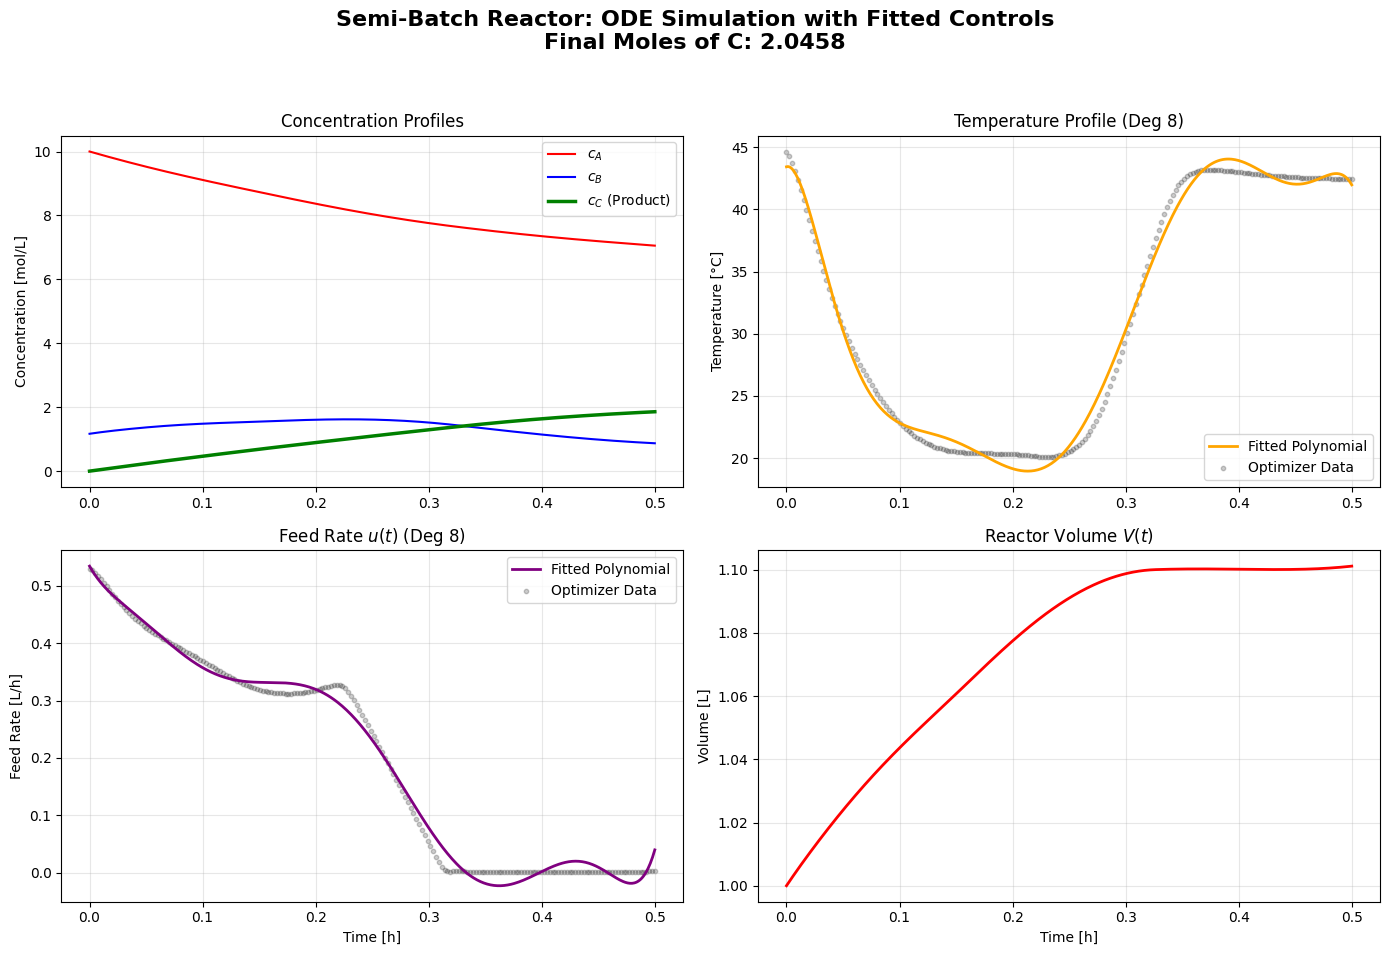

In [ ]:
from scipy.integrate import solve_ivp
from sklearn.metrics import r2_score


k1o, k2o = 4.0, 800.0
E1, E2 = 6e3, 20e3
R_gas = 8.31
cB_in = 20.0
tf = 0.5
cAo, cBo, cCo, Vo = 10.0, 1.1685, 0.0, 1.0


t_opt = sol.value(T_ctrl)
u_opt = sol.value(u_ctrl)
N_points = len(t_opt)
time_points = np.linspace(0, tf, N_points)

def fit_best_poly(x, y, target_r2=0.99, max_deg=15):
    for deg in range(1, max_deg + 1):
        coeffs = np.polyfit(x, y, deg)
        p = np.poly1d(coeffs)
        if r2_score(y, p(x)) >= target_r2:
            return p
    return np.poly1d(np.polyfit(x, y, max_deg))


poly_T = fit_best_poly(time_points, t_opt)
poly_u = fit_best_poly(time_points, u_opt)


def reactor_dynamics(t, y, pT, pu):
    cA, cB, cC, V = y


    T_celsius = pT(t)
    T_K = T_celsius + 273.15
    u = max(0, pu(t))


    k1 = k1o * np.exp(-E1 / (R_gas * T_K))
    k2 = k2o * np.exp(-E2 / (R_gas * T_K))


    dcA = -k1 * cA * cB - (u / V) * cA
    dcB = -k1 * cA * cB + (u / V) * (cB_in - cB)
    dcC = k1 * cA * cB - k2 * cC - (u / V) * cC
    dV  = u
    return [dcA, dcB, dcC, dV]


t_eval = np.linspace(0, tf, 500)
sol_sim = solve_ivp(reactor_dynamics, (0, tf), [cAo, cBo, cCo, Vo],
                    t_eval=t_eval, args=(poly_T, poly_u), method='RK45')


moles_C_final = sol_sim.y[2][-1] * sol_sim.y[3][-1]


print(f"Total Moles of C (cC * V): {moles_C_final:.6f} mol")


fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Semi-Batch Reactor: ODE Simulation with Fitted Controls\nFinal Moles of C: {moles_C_final:.4f}",
             fontsize=16, fontweight='bold')

# Plot 1: Concentrations
axs[0,0].plot(sol_sim.t, sol_sim.y[0], 'r', label='$c_A$')
axs[0,0].plot(sol_sim.t, sol_sim.y[1], 'b', label='$c_B$')
axs[0,0].plot(sol_sim.t, sol_sim.y[2], 'g', lw=2.5, label='$c_C$ (Product)')
axs[0,0].set_title("Concentration Profiles", fontsize=12)
axs[0,0].set_ylabel("Concentration [mol/L]")
axs[0,0].legend()
axs[0,0].grid(True, alpha=0.3)

# Plot 2: Temperature Curve (Fitted vs Raw)
axs[0,1].plot(t_eval, poly_T(t_eval), 'orange', lw=2, label='Fitted Polynomial')
axs[0,1].scatter(time_points, t_opt, color='black', s=10, alpha=0.2, label='Optimizer Data')
axs[0,1].set_title(f"Temperature Profile (Deg {poly_T.order})", fontsize=12)
axs[0,1].set_ylabel("Temperature [°C]")
axs[0,1].legend()
axs[0,1].grid(True, alpha=0.3)

# Plot 3: Feedrate Curve (Fitted vs Raw)
axs[1,0].plot(t_eval, poly_u(t_eval), 'purple', lw=2, label='Fitted Polynomial')
axs[1,0].scatter(time_points, u_opt, color='black', s=10, alpha=0.2, label='Optimizer Data')
axs[1,0].set_title(f"Feed Rate $u(t)$ (Deg {poly_u.order})", fontsize=12)
axs[1,0].set_xlabel("Time [h]")
axs[1,0].set_ylabel("Feed Rate [L/h]")
axs[1,0].legend()
axs[1,0].grid(True, alpha=0.3)

# Plot 4: Volume Curve
axs[1,1].plot(sol_sim.t, sol_sim.y[3], 'red', lw=2)
axs[1,1].set_title("Reactor Volume $V(t)$", fontsize=12)
axs[1,1].set_xlabel("Time [h]")
axs[1,1].set_ylabel("Volume [L]")
axs[1,1].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

The volume plot decreases because the fitted polynomial of u also aquires negative values. ths decreases V.


         FINAL SEMI-BATCH REACTOR RESULTS         
Optimal Settings Found:
 > Temperature (T):      45.00 °C
 > Feed Rate (u):         0.20 L/h
--------------------------------------------------
Final Concentrations (at t = 0.5 h):
 > cA:                   7.282970 mol/L
 > cB:                   1.072516 mol/L
 > cC (Product):         1.624606 mol/L
--------------------------------------------------
Final Volume (V):        1.1000 L
TOTAL MOLES OF C:        1.787067 mol



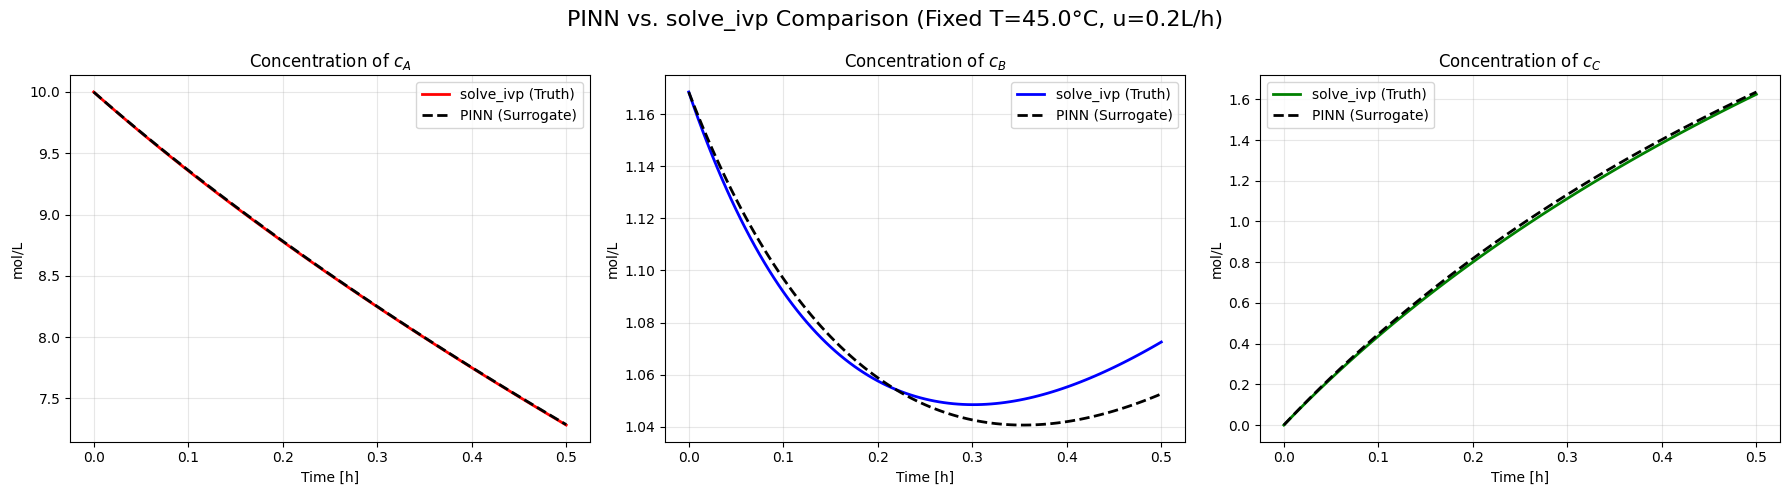

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


pytorch_model.eval()


T_range = np.linspace(20, 50, 31)  # 20°C to 50°C
u_range = np.linspace(0, 0.2, 21) # 0 to 0.2 L/h (to respect V_max over 0.5h)
tf = 0.5
N_steps = 100
dt = tf / N_steps
x0 = np.array([10.0, 1.1685, 0.0, 1.0]) # Initial [cA, cB, cC, V]


best_moles_C = -np.inf
best_T = None
best_u = None



with torch.no_grad():
    for T_const in T_range:
        for u_const in u_range:
            current_state = x0.copy()
            for _ in range(N_steps):

                pinn_input = torch.FloatTensor(np.append(current_state, [u_const, T_const])).view(1, -1)
                dx_dt = pytorch_model(pinn_input).numpy().flatten()
                current_state += dx_dt * dt


            final_moles = current_state[2] * current_state[3]
            if final_moles > best_moles_C:
                best_moles_C = final_moles
                best_T = T_const
                best_u = u_const


def analytical_rhs(t, y):
    cA, cB, cC, V = y
    T_K = best_T + 273.15
    # Kinetics from Table 7
    k1 = 4.0 * np.exp(-6000 / (8.31 * T_K))
    k2 = 800.0 * np.exp(-20000 / (8.31 * T_K))
    cB_in = 20.0

    dcA = -k1 * cA * cB - (best_u / V) * cA
    dcB = -k1 * cA * cB + (best_u / V) * (cB_in - cB)
    dcC = k1 * cA * cB - k2 * cC - (best_u / V) * cC
    dV  = best_u
    return [dcA, dcB, dcC, dV]

t_eval = np.linspace(0, tf, N_steps + 1)
sol_ivp = solve_ivp(analytical_rhs, (0, tf), x0, t_eval=t_eval, method='RK45')


cA_f, cB_f, cC_f, V_f = sol_ivp.y[:, -1]
total_moles_C = cC_f * V_f


print("\n" + "="*50)
print(f"{'FINAL SEMI-BATCH REACTOR RESULTS':^50}")
print("="*50)
print(f"Optimal Settings Found:")
print(f" > Temperature (T):      {best_T:.2f} °C")
print(f" > Feed Rate (u):         {best_u:.2f} L/h")
print("-" * 50)
print(f"Final Concentrations (at t = {tf} h):")
print(f" > cA:                   {cA_f:.6f} mol/L")
print(f" > cB:                   {cB_f:.6f} mol/L")
print(f" > cC (Product):         {cC_f:.6f} mol/L")
print("-" * 50)
print(f"Final Volume (V):        {V_f:.4f} L")
print(f"TOTAL MOLES OF C:        {total_moles_C:.6f} mol")
print("="*50 + "\n")


pinn_trajectory = [x0.copy()]
curr_pinn = x0.copy()
with torch.no_grad():
    for _ in range(len(t_eval) - 1):
        pinn_in = torch.FloatTensor(np.append(curr_pinn, [best_u, best_T])).view(1, -1)
        dx_dt = pytorch_model(pinn_in).numpy().flatten()
        curr_pinn += dx_dt * dt
        pinn_trajectory.append(curr_pinn.copy())
pinn_trajectory = np.array(pinn_trajectory).T

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"PINN vs. solve_ivp Comparison (Fixed T={best_T}°C, u={best_u}L/h)", fontsize=16)

labels = ['$c_A$', '$c_B$', '$c_C$']
colors = ['red', 'blue', 'green']

for i in range(3):
    axs[i].plot(sol_ivp.t, sol_ivp.y[i], color=colors[i], linestyle='-', lw=2, label='solve_ivp (Truth)')
    axs[i].plot(t_eval, pinn_trajectory[i], color='black', linestyle='--', lw=2, label='PINN (Surrogate)')
    axs[i].set_title(f"Concentration of {labels[i]}")
    axs[i].set_xlabel("Time [h]")
    axs[i].set_ylabel("mol/L")
    axs[i].legend()
    axs[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

A grid search algo to get best possible const T and u for this. plot also describes the accuracy of PINN training with solve_ivp(actual DE)

<>:119: SyntaxWarning: invalid escape sequence '\D'
<>:127: SyntaxWarning: invalid escape sequence '\D'
<>:119: SyntaxWarning: invalid escape sequence '\D'
<>:127: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_148/983931297.py:119: SyntaxWarning: invalid escape sequence '\D'
  plt.title(f"Optimal Feed Rate (u)\nmax $\Delta$u={delta_u_max}")
/tmp/ipykernel_148/983931297.py:127: SyntaxWarning: invalid escape sequence '\D'
  plt.title(f"Optimal Temperature (T)\nmax $\Delta$T={delta_T_max}")


This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:    44004
Number of nonzeros in inequality constraint Jacobian.:    23997
Number of nonzeros in Lagrangian Hessian.............:    36001

Total number of variables............................:    12004
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:     8004
Total number of inequality constraints...............:    11999
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:     7998
        inequality constraints with only upper bounds:     4001

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0 -0.0000000e+00 1.00e+01 1.00e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

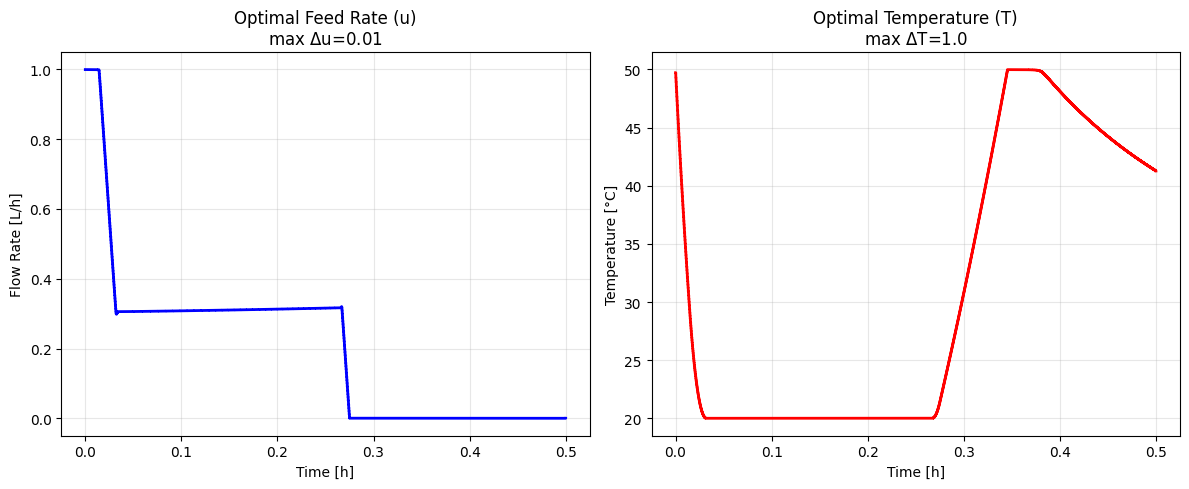

Optimal final moles of C: 2.0526


In [ ]:
import casadi as ca
import numpy as np
import matplotlib.pyplot as plt


tf = 0.5
N = 2000
dt = tf / N

k1o, k2o = 4.0, 800.0
E1, E2 = 6000.0, 20000.0
R = 8.314
dH1, dH2 = -3e4, -1e4
cBin = 20.0

T_min, T_max = 20.0, 50.0
u_min, u_max = 0.0, 1.0
V_max = 1.1
qrx_max = 1.5e5


delta_T_max = 1.0
delta_u_max = 0.01


cA0, cB0, cC0, V0 = 10.0, 1.1685, 0.0, 1.0


opti = ca.Opti()

X = opti.variable(4, N+1)  # States: [cA, cB, cC, V]
U = opti.variable(2, N)    # Controls: [u, T]


opti.set_initial(X[3, :], V0)
opti.set_initial(U[0, :], 0.5)
opti.set_initial(U[1, :], 35.0)

#  maximize final moles of C
opti.minimize(-(X[2, N] * X[3, N]))


def ode_rhs(x, u_ctrl):
    cA, cB, cC, V = x[0], x[1], x[2], x[3]
    u, T_c = u_ctrl[0], u_ctrl[1]
    T_k = T_c + 273.15

    k1 = k1o * ca.exp(-E1 / (R * T_k))
    k2 = k2o * ca.exp(-E2 / (R * T_k))

    dcA = -k1 * cA * cB - (u / V) * cA
    dcB = -k1 * cA * cB + (u / V) * (cBin - cB)
    dcC = k1 * cA * cB - k2 * cC - (u / V) * cC
    dV = u

    return ca.vertcat(dcA, dcB, dcC, dV)


for k in range(N):

    k1 = ode_rhs(X[:, k],          U[:, k])
    k2 = ode_rhs(X[:, k] + dt/2*k1, U[:, k])
    k3 = ode_rhs(X[:, k] + dt/2*k2, U[:, k])
    k4 = ode_rhs(X[:, k] + dt*k3,   U[:, k])
    x_next = X[:, k] + dt/6 * (k1 + 2*k2 + 2*k3 + k4)
    opti.subject_to(X[:, k+1] == x_next)


    if k < N - 1:

        opti.subject_to(opti.bounded(-delta_u_max, U[0, k+1] - U[0, k], delta_u_max))

        opti.subject_to(opti.bounded(-delta_T_max, U[1, k+1] - U[1, k], delta_T_max))


opti.subject_to(X[:, 0] == ca.vertcat(cA0, cB0, cC0, V0))
opti.subject_to(opti.bounded(u_min, U[0, :], u_max))
opti.subject_to(opti.bounded(T_min, U[1, :], T_max))
opti.subject_to(X[3, :] <= V_max)


for k in range(N):
    T_k = U[1, k] + 273.15
    k1 = k1o * ca.exp(-E1 / (R * T_k))
    k2 = k2o * ca.exp(-E2 / (R * T_k))
    q_gen = (-dH1) * k1 * X[0, k] * X[1, k] * X[3, k] + (-dH2) * k2 * X[2, k] * X[3, k]
    opti.subject_to(q_gen <= qrx_max)


opts = {
    "ipopt": {
        "max_iter": 50000,
        "print_level": 5, # Shows progress so you can see if it's converging
        "acceptable_tol": 1e-6,
        "acceptable_obj_change_tol": 1e-4
    }
}
opti.solver("ipopt", opts)

try:
    sol = opti.solve()
    print(f"Optimal final moles of C: {-sol.value(opti.f):.4f}")
except:

    print("Solver failed to converge.")
    print("Last volume value:", opti.debug.value(X[3, -1]))
    print("Last Temp value:", opti.debug.value(U[1, -1]))


t_grid = np.linspace(0, tf, N)
u_opt = sol.value(U[0, :])
T_opt = sol.value(U[1, :])

plt.figure(figsize=(12, 5))

# Graph 1: Feedrate
plt.subplot(1, 2, 1)
plt.step(t_grid, u_opt, 'b', where='post', lw=2)
plt.title(f"Optimal Feed Rate (u)\nmax $\Delta$u={delta_u_max}")
plt.xlabel("Time [h]")
plt.ylabel("Flow Rate [L/h]")
plt.grid(True, alpha=0.3)

# Graph 2: Temperature
plt.subplot(1, 2, 2)
plt.step(t_grid, T_opt, 'r', where='post', lw=2)
plt.title(f"Optimal Temperature (T)\nmax $\Delta$T={delta_T_max}")
plt.xlabel("Time [h]")
plt.ylabel("Temperature [°C]")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Optimal final moles of C: {-sol.value(opti.f):.4f}")

This gives the same algo but instead of using PINN to estimate states it uses Solve_IVP to estimate states.(SolveIVP + CasADI)